# Project steps 
1. context
2. dvc
3. metrices
4. mlflow
5. Hyperparameter Tuning (Optuna)


# 1. Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents




In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv('../data/raw/churn.csv')
df.sample(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5280,6574-MCOEH,Female,0,Yes,Yes,33,Yes,Yes,DSL,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,79.15,2531.4,No
1117,6900-RBKER,Male,0,No,No,52,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Two year,Yes,Credit card (automatic),89.45,4577.75,No


In [7]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


- for valriable have two categories we will replace them with 0 and 1
- for those have 3-4 categories we will use one hot encoding


In [8]:
binary_cols=[col for col in df.columns if df[col].nunique() == 2]
df[binary_cols].sample(2)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
5156,Male,0,No,No,Yes,No,No
6205,Male,0,Yes,No,Yes,Yes,Yes


In [9]:
# Binary categorical columns (2 unique values)
binary_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn' 
]

# Map Yes/No and Male/Female to 0/1
df[binary_cols] = df[binary_cols].replace({
    'Yes': 1, 'No': 0,
    'Male': 1, 'Female': 0
})
df[binary_cols]=df[binary_cols].astype(int)
df[binary_cols].head()

/tmp/ipykernel_2244906/1852011210.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


In [10]:
multi_cat_cols=[col for col in df.columns if df[col].nunique() > 2]
df[multi_cat_cols].head()

,customerID,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Electronic check,29.85,29.85
1,5575-GNVDE,34,No,DSL,Yes,No,Yes,No,No,No,One year,Mailed check,56.95,1889.5
2,3668-QPYBK,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Mailed check,53.85,108.15
3,7795-CFOCW,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check,70.70,151.65


In [11]:
# Categorical columns with > 2 unique values
multi_cat_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

# One-hot encode
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
! python ../scripts/prepare_processed_data.py

#### Cleaning

In [13]:
df.drop(columns=['customerID'], inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
bool_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
df[bool_cols] = df[bool_cols].astype(bool)
df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043,7043,7043.000000,7043,7043,7043.000000,7032.000000,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,NaN,NaN,2,2,NaN,2,2,NaN,NaN,2,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,False,False,NaN,True,True,NaN,NaN,False,...,False,False,False,False,False,False,False,False,False,False
freq,NaN,NaN,3641,4933,NaN,6361,4171,NaN,NaN,5174,...,4999,5517,4336,5517,4311,5570,5348,5521,4678,5431
mean,0.504756,0.162147,NaN,NaN,32.371149,NaN,NaN,64.761692,2283.300441,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.500013,0.368612,NaN,NaN,24.559481,NaN,NaN,30.090047,2266.771362,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,NaN,NaN,0.000000,NaN,NaN,18.250000,18.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,0.000000,NaN,NaN,9.000000,NaN,NaN,35.500000,401.450000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.000000,0.000000,NaN,NaN,29.000000,NaN,NaN,70.350000,1397.475000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,0.000000,NaN,NaN,55.000000,NaN,NaN,89.850000,3794.737500,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   bool   
 3   Dependents                             7043 non-null   bool   
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   bool   
 6   PaperlessBilling                       7043 non-null   bool   
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   bool   
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [15]:
corr_matrix=df.corr(numeric_only=True)
churn_corr = corr_matrix[['Churn']].sort_values(by='Churn', ascending=False)
churn_corr

,Churn
Churn,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
MonthlyCharges,0.193356
PaperlessBilling,0.191825
SeniorCitizen,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
PhoneService,0.011942


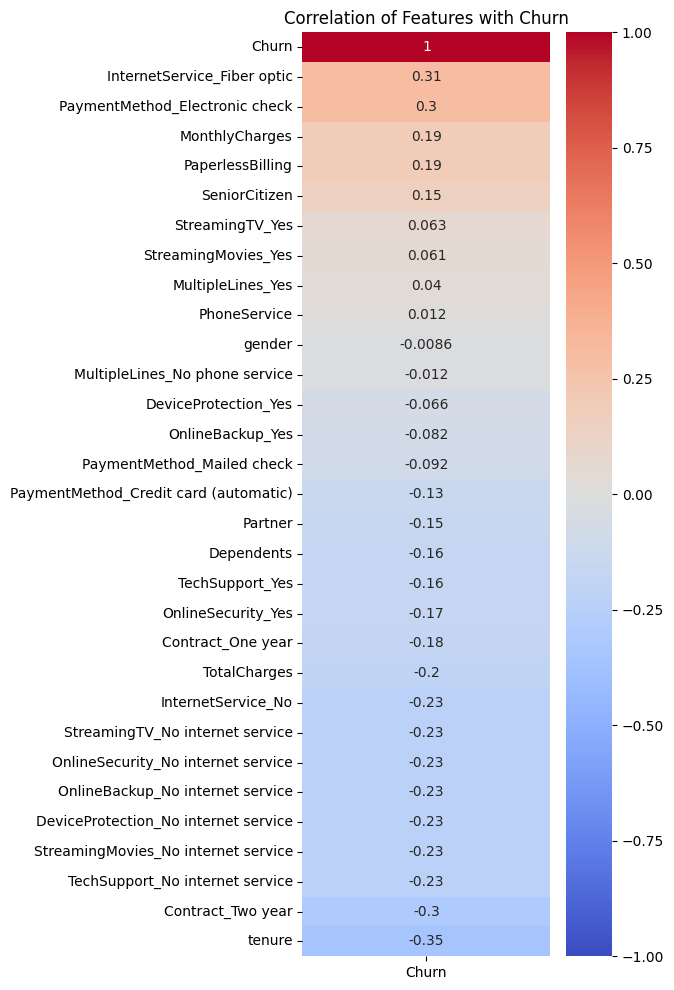

In [16]:
# plot

plt.figure(figsize=(4, 12))
sns.heatmap(churn_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Features with Churn')
plt.show()

#### what we learn from this Graph :
- Negative (lower value → less likely to churn):
    - tenure (-0.35) → Customers who stay longer are less likely to churn.
    - Contract_Two year (-0.30) → Customers on long-term contracts churn much less.
    - Contract_One year (-0.18) → Same trend but weaker than two-year contracts.

    
- Positive (higher value → more likely to churn):
    - InternetService_Fiber optic (+0.31) → Fiber optic users churn more in this dataset.
    - PaymentMethod_Electronic check (+0.30) → Customers paying electronically via check churn more.

#### Look for multicolinearity (VIF)
The Variance Inflation Factor (VIF) is a measure used in regression analysis to detect multicollinearity among independent variables 

#### Interpretation
- VIF = 1 → No correlation with other variables
- 1 < VIF < 5 → Moderate correlation (usually acceptable)
- VIF ≥ 5 (or 10) → High multicollinearity (problematic)

In [17]:
# We need to collapse redundant columns before running VIF
df['No_internet_service'] = (
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service'] |
    df['DeviceProtection_No internet service'] |
    df['TechSupport_No internet service'] |
    df['StreamingTV_No internet service'] |
    df['StreamingMovies_No internet service']
).astype(int)

# Drop the original redundant dummies
drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns=drop_cols)

# Handle PhoneService redundancy
if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])

In [15]:
## Prepare X
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [16]:
# Run VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Remove rows with missing or infinite values
X = X.select_dtypes(include=[np.number])
X = X.replace([np.inf, -np.inf], np.nan).dropna()
X = X.dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by='VIF', ascending=False)

vif_data

/home/zahra/.pyenv/versions/3.10.8/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
11,InternetService_No,inf
23,No_internet_service,inf
5,PhoneService,1773.528816
7,MonthlyCharges,866.089640
10,InternetService_Fiber optic,148.500814
24,No_phone_service,60.842267
17,StreamingMovies_Yes,24.156394
16,StreamingTV_Yes,24.080019
8,TotalCharges,10.811490
4,tenure,7.584453


- Clearly we can see there's multicolinearity between features
- So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
- Or use tree based models which are less sensitive to multicollinearity
- In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.

# 2. dvc
we can put churn.csv into Git, but datasets can become very large. Git is designed primarily for source code, not large datasets and binary files.
DVC solves this by keeping the actual dataset outside normal Git history while Git tracks a small metadata file describing the dataset version.

Conceptually:
```
Git
│
├── train.py
├── config.yaml
├── requirements.txt
└── churn.csv.dvc       ← small metadata file
                         │
                         ▼
                    DVC storage
                         │
                         ▼
                    churn.csv
```
``` bash
pip install dvc
dvc init
## track dataset
dvc add raw/churn.dvc

```


In [ ]:
! python ../scripts/test_pipeline_phase1_data_features.py


# 3. Train Model choose metrix 

### 3.1  metrics
- Recall@K → “How many churners did I catch in top K?”
- Precision–Recall trade-off → “Catch more vs be more accurate”
- Lift@K → “How much better than random?”
- PR-AUC → “Overall quality of finding churners”


### 3.2 model
decision tree why ?

becouse there are many correlation between features and decision tree can handle this well


In [20]:
df['Churn'].value_counts()

Churn
False    5174
True     1869
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report
import pandas as pd
import time


# Prepare data
X = df.drop(columns=['Churn'])
y = df['Churn']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

THRESHOLD = 0.3  # lower than 0.5 to boost recall (see next to choose the right value)

#### RandomForest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import lightgbm as lgb
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # handles imbalance for you
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]

print("Threshold tuning for RandomForest")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

#### LightGBM classifier

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Training timer
start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

#### XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(X_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

#### Test Phase 2

In [ ]:
! python ../scripts/test_pipeline_phase2_modeling.py

# 4. mlflow


In [23]:
import mlflow
import mlflow.xgboost

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

params = {
    "n_estimators": 300,
    "max_depth": 6,
    "learning_rate": 0.05,
    "random_state": 42
}

mlflow.set_experiment("Telco Churn")

with mlflow.start_run():

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    mlflow.log_params(params)

    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("f1", f1)

    mlflow.xgboost.log_model(
        model,
        "model"
    )

    print("Accuracy:", accuracy)
    print("F1:", f1)

2026/09/25 14:58:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy: 0.7934705464868701
F1: 0.5776487663280117


In [ ]:
! cd /home/zahra/Churn_model

mlflow server \
  --host 0.0.0.0 \
  --port 5000 \
  --backend-store-uri sqlite:////home/zahra/Churn_model/mlflow.db \
  --default-artifact-root /home/zahra/Churn_model/mlruns \
  --allowed-hosts 192.168.2.130:5000 \
  --cors-allowed-origins http://192.168.2.130:5000

Backend store URI not provided. Using sqlite:///mlflow.db
Registry store URI not provided. Using backend store URI.
[MLflow] Security middleware enabled. Allowed hosts: 192.168.2.130:5000. CORS origins: http://192.168.2.130:5000.
2026/09/25 12:49:54 INFO:     Uvicorn running on http://0.0.0.0:5000 (Press CTRL+C to quit)
2026/09/25 12:49:54 INFO:     Started parent process [2138754]
2026/09/25 12:49:58 INFO:     Started server process [2138762]
2026/09/25 12:49:58 INFO:     Waiting for application startup.
2026/09/25 12:49:58 INFO:     Started server process [2138761]
2026/09/25 12:49:58 INFO:     Waiting for application startup.
2026/09/25 12:49:58 INFO:     Started server process [2138763]
2026/09/25 12:49:58 INFO:     Waiting for application startup.
2026/09/25 12:49:58 INFO:     Started server process [2138760]
2026/09/25 12:49:58 INFO:     Waiting for application startup.
2026/09/25 12:49:58 INFO:     Application startup complete.
2026/09/25 12:49:58 INFO:     Application startup c

# 5. Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

```
                ┌──────────────┐
                │    Optuna    │
                └──────┬───────┘
                       │
                 hyperparameters
                       │
                       ▼
                ┌──────────────┐
                │   XGBoost    │
                └──────┬───────┘
                       │
                     train
                       │
                       ▼
                    metrics
                       │
                       ▼
                  ┌─────────┐
                  │ MLflow  │
                  └─────────┘
```

In [24]:
import mlflow
import mlflow.xgboost
import optuna

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score


# ============================================================
# 1. SPLIT DATA
# ============================================================

X = df.drop(columns=["Churn"])
y = df["Churn"]

# Train + Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train + Validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)


# ============================================================
# 2. OPTUNA
# ============================================================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),

        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    model.fit(X_train, y_train)

    predictions = model.predict(X_valid)

    recall = recall_score(y_valid, predictions)

    return recall


# ============================================================
# 3. RUN OPTUNA
# ============================================================

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=30)

print("Best parameters:")
print(study.best_params)

print("Best validation recall:")
print(study.best_value)


# ============================================================
# 4. TRAIN FINAL MODEL WITH BEST PARAMETERS
# ============================================================

best_params = {
    **study.best_params,
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": "logloss"
}

mlflow.set_experiment("Telco Churn")

with mlflow.start_run():

    model = XGBClassifier(**best_params)

    model.fit(X_train, y_train)

    # Test predictions
    predictions = model.predict(X_test)

    # Test metrics
    accuracy = accuracy_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    # Log parameters
    mlflow.log_params(best_params)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)

    # Log model
    mlflow.xgboost.log_model(
        model,
        "model"
    )

    print("\nFinal Test Results")
    print("------------------")
    print("Accuracy:", accuracy)
    print("Recall:", recall)
    print("F1:", f1)

[I 2026-09-25 14:58:43,557] A new study created in memory with name: no-name-51008820-4cea-42f7-9fc6-31785341d1ab
[I 2026-09-25 14:58:43,901] Trial 0 finished with value: 0.49498327759197325 and parameters: {'n_estimators': 515, 'learning_rate': 0.1397666759665928, 'max_depth': 3, 'subsample': 0.6383360315575003, 'colsample_bytree': 0.6840762315528388, 'min_child_weight': 10, 'gamma': 3.2708055724659464, 'reg_alpha': 1.109109360399359, 'reg_lambda': 0.34253759664191863}. Best is trial 0 with value: 0.49498327759197325.
[I 2026-09-25 14:58:44,829] Trial 1 finished with value: 0.4916387959866221 and parameters: {'n_estimators': 459, 'learning_rate': 0.14544716592871107, 'max_depth': 10, 'subsample': 0.750173083247107, 'colsample_bytree': 0.5846313301888677, 'min_child_weight': 8, 'gamma': 0.18022615022666166, 'reg_alpha': 2.709361551165901, 'reg_lambda': 2.8532026746674166}. Best is trial 0 with value: 0.49498327759197325.
[I 2026-09-25 14:58:45,267] Trial 2 finished with value: 0.508361

Best parameters:
{'n_estimators': 757, 'learning_rate': 0.12547192165066628, 'max_depth': 9, 'subsample': 0.8175097211710545, 'colsample_bytree': 0.8094913273058781, 'min_child_weight': 1, 'gamma': 3.5796756445561435, 'reg_alpha': 4.360654443373813, 'reg_lambda': 3.7440399650379868}
Best validation recall:
0.5351170568561873


2026/09/25 14:59:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Final Test Results
------------------
Accuracy: 0.8041163946061036
Recall: 0.5294117647058824
F1: 0.5892857142857143


In [3]:
! python ../scripts/run_pipeline.py


2026-09-25 15:14:15,990 | INFO | ======================================================================
2026-09-25 15:14:15,990 | INFO | TELCO CHURN — OPTUNA + XGBOOST + MLFLOW
2026-09-25 15:14:15,990 | INFO | ======================================================================
2026-09-25 15:14:16,974 | INFO | [1/8] Loading data...
2026-09-25 15:14:16,997 | INFO | Raw shape: (7043, 21)
2026-09-25 15:14:16,997 | INFO | Number of rows: 7043
2026-09-25 15:14:17,004 | INFO | [2/8] Validating data...
✅ Data validation PASSED
2026-09-25 15:14:17,011 | INFO | Data validation PASSED
2026-09-25 15:14:17,011 | INFO | [3/8] Preprocessing...
2026-09-25 15:14:17,123 | INFO | Processed shape: (7043, 20)
2026-09-25 15:14:17,123 | INFO | Processed data saved to: /home/zahra/Churn_model/data/processed/churn_processed.csv
2026-09-25 15:14:17,136 | INFO | [4/8] Building features...
🔧 Starting feature engineering on 20 columns...
   📊 Found 15 categorical and 5 numeric columns
   🔢 Binary features: 5 | 

In [ ]:
mlflow server \
  --host 0.0.0.0 \
  --port 5000 \
  --backend-store-uri sqlite:////home/zahra/Churn_model/notebooks/mlflow.db\
  --default-artifact-root /home/zahra/Churn_model/mlruns \
  --allowed-hosts 192.168.2.130:5000 \
  --cors-allowed-origins http://192.168.2.130:5000